In [6]:
#packages
import requests
import pandas as pd
import json
from glob import glob
from pathlib import Path
import csv
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import plotly.express as px

import geopandas as gpd

Text(0.5, 1.0, 'Selected Census Tracts (highlighted)')

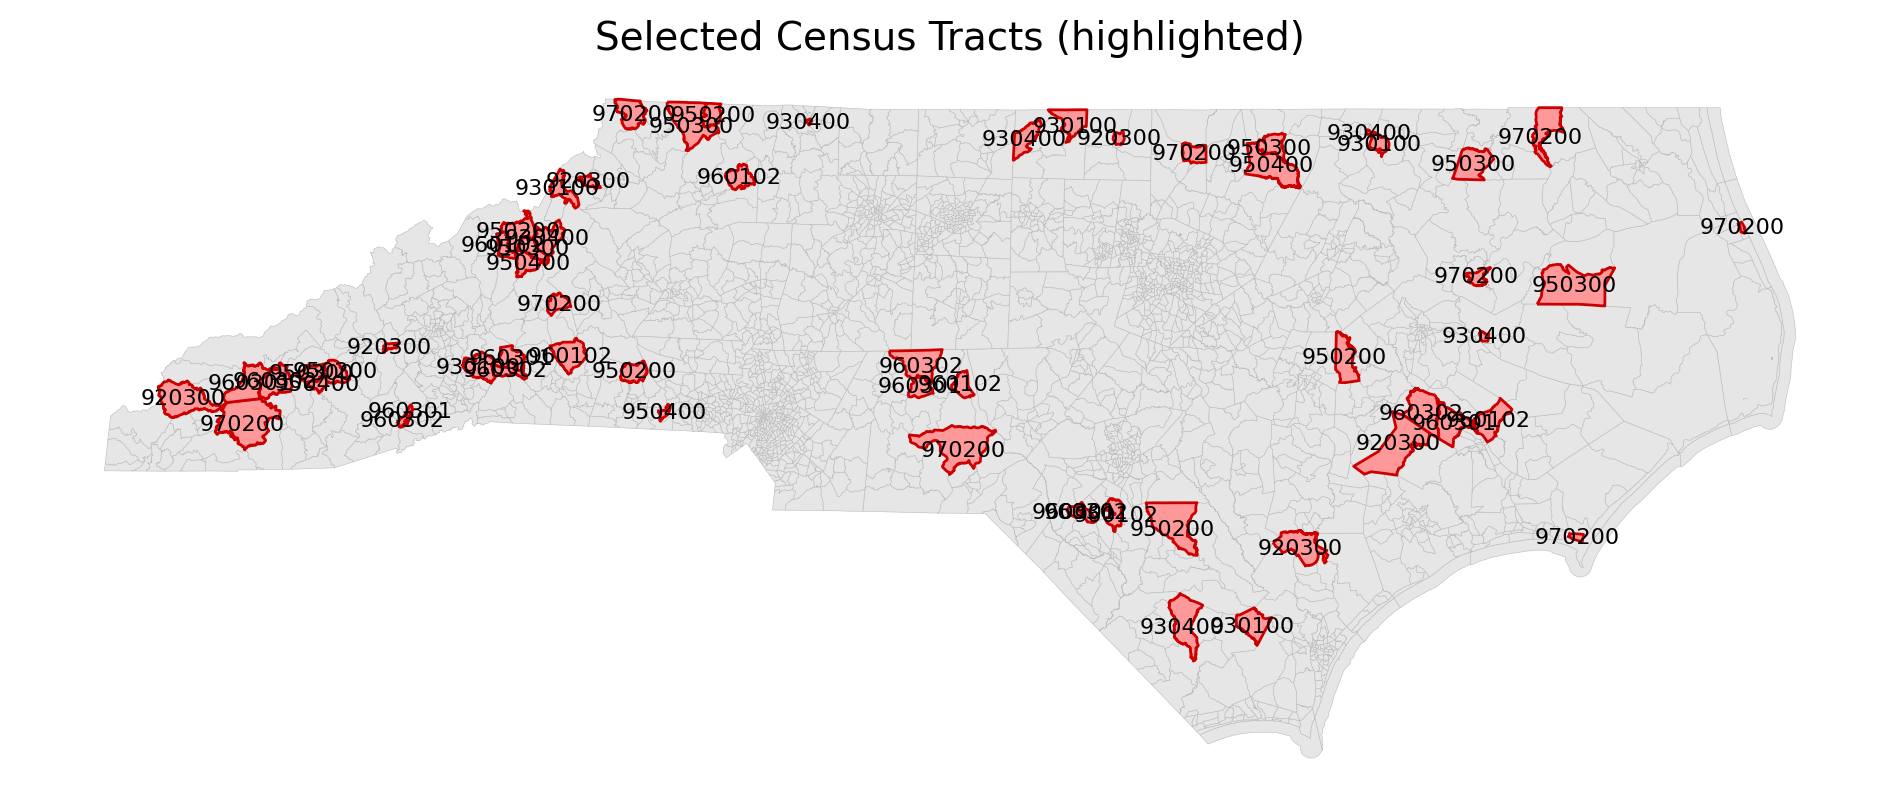

In [13]:
target_tracts = [
    "960301","950300","970200","930100","950400",
    "960102","920300","950200","960302","930400"
]

target_tracts = [t.zfill(6) for t in target_tracts]

tract_shp = "data_raw/tl_2022_37_tract"   # change if you have a .shp file path

out_path = "selected_outlier_tracts_map.png"

tract_geo = gpd.read_file(tract_shp)
# make sure it's in WGS84 for plotting
tract_geo = tract_geo.to_crs(epsg=4326)

# get or create a 6-digit TRACT id (last 6 digits of GEOID)
if 'TRACT' not in tract_geo.columns:
    if 'GEOID' in tract_geo.columns:
        tract_geo['TRACT'] = tract_geo['GEOID'].astype(str).str[-6:]
    else:
        raise KeyError("tract_geo must contain 'TRACT' or 'GEOID'")

tract_geo['TRACT'] = tract_geo['TRACT'].astype(str).str.zfill(6)

# subset the tracts you care about
subset_gdf = tract_geo[tract_geo['TRACT'].isin(target_tracts)].copy()

# full NC tracts in light gray, then highlighted tracts on top + labels
fig, ax = plt.subplots(1, 1, figsize=(12, 12), dpi=200)

# background: all tracts (light)
tract_geo.plot(ax=ax, color="#E6E6E6", edgecolor="#BBBBBB", linewidth=0.2)

# highlighted tracts: selected
subset_gdf.plot(ax=ax, facecolor="#ff9999", edgecolor="#cc0000", linewidth=1.0, zorder=5)

# add labels at centroid -- if polygons are multipart, use representative_point()
for idx, row in subset_gdf.iterrows():
    # use representative_point() to place label inside polygon reliably
    point = row.geometry.representative_point()
    ax.annotate(
        row["TRACT"],
        (point.x, point.y),
        ha="center",
        va="center",
        fontsize=8,
        color="black",
        zorder=6
    )

ax.set_axis_off()
ax.set_title("Selected Census Tracts (highlighted)", fontsize=14)

# save and show
#plt.savefig(out_path, bbox_inches='tight', dpi=300)
#print(f"Saved: {out_path}")
#plt.show()

In [15]:
# 1) counts per tract
vc = subset_gdf['TRACT'].value_counts()
print("Counts per TRACT (show >1):")
print(vc[vc > 1])

# 2) show full rows for a duplicated tract (example pick first duplicated id)
dup_ids = vc[vc > 1].index.tolist()
if dup_ids:
    sample = dup_ids[0]
    print(f"\nExample duplicate TRACT: {sample}")
    print(subset_gdf[subset_gdf['TRACT']==sample])
else:
    print("No duplicates found in subset_gdf.")



Counts per TRACT (show >1):
TRACT
970200    9
960301    6
960302    6
920300    6
930400    6
960102    6
950200    6
950300    6
930100    5
950400    4
Name: count, dtype: int64

Example duplicate TRACT: 970200
     STATEFP COUNTYFP TRACTCE        GEOID  NAME           NAMELSAD  MTFCC  \
87        37      031  970200  37031970200  9702  Census Tract 9702  G5020   
118       37      055  970200  37055970200  9702  Census Tract 9702  G5020   
536       37      009  970200  37009970200  9702  Census Tract 9702  G5020   
728       37      073  970200  37073970200  9702  Census Tract 9702  G5020   
888       37      113  970200  37113970200  9702  Census Tract 9702  G5020   
1025      37      111  970200  37111970200  9702  Census Tract 9702  G5020   
1032      37      077  970200  37077970200  9702  Census Tract 9702  G5020   
1084      37      117  970200  37117970200  9702  Census Tract 9702  G5020   
1459      37      153  970200  37153970200  9702  Census Tract 9702  G5020   

     F